# End2Race PPO 全实验审计：BC 至 Group 9

## TL;DR

- 固定 Austin600 面板上，最低碰撞为 **11/600**：G5 clip 0.20 U30 与其逐位复现后延长得到的 G7 U40。
- PPO **显著缓解但未消除** BC 继承的“超车后并线、尾部高侧滑撞对手”问题。BC 严格判据 8 例；G5 U30 为 3 例、G7 U40 为 5 例、G9 hard-neighbor U45 为 1 例。
- hard-neighbor U45 对该特定机制最强，但总体碰撞为 17，且相对 BC 新增 10 个碰撞场景；它把失败转移到其他车车接触，不能称为总体解决。
- 这是单 seed、固定选择面板的描述性证据；全部 checkpoint 的多重比较校正后，没有单个结果达到常规显著性门槛。


## Context & Methods

本 notebook 读取 `analyze_all_experiments.py` 生成的有界 CSV/JSON。原始输入包括 16 个 run 的配置、415 条 formal-update metrics、92 个 PPO eval 面板（另有 1 个 BC 面板）、55,200 条 PPO-vs-BC 逐 episode 配对记录，以及 600 条 BC 自参考行和对应 NPZ trace。

“甩尾”采用可复核的复合判据：车车碰撞；参考帧前相对赛道进度曾越过 0；碰撞时对手位于 ego 后方且更接近车尾；前 0.5 秒横向间距至少闭合 0.10 m；由位置差分得到的最大绝对侧滑角达到阈值。主阈值为 5°，同时报告 3°/8°敏感性。trace 未保存模拟器真实 `slip_angle` 或接触点，因此这是机制级代理，不是接触动力学的直接观测。


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path.cwd()
if not (OUT / 'analysis_summary.json').exists():
    OUT = Path('analysis_results/ppo_all_experiments_0723')

summary = json.loads((OUT / 'analysis_summary.json').read_text())
configs = pd.read_csv(OUT / 'run_config_matrix.csv')
train = pd.read_csv(OUT / 'training_updates.csv')
train_summary = pd.read_csv(OUT / 'training_run_summary.csv')
panels = pd.read_csv(OUT / 'eval_panels.csv')
episodes = pd.read_csv(OUT / 'eval_episode_comparison.csv')
tail = pd.read_csv(OUT / 'tail_issue_by_panel.csv')
features = pd.read_csv(OUT / 'collision_episode_features.csv')
frequency = pd.read_csv(OUT / 'collision_scenario_frequency.csv')
paired = pd.read_csv(OUT / 'selected_paired_comparisons.csv')
logical = pd.read_csv(OUT / 'logical_clip020_45u_path.csv')

print({
    'runs': len(configs),
    'formal_updates': len(train),
    'eval_panels': len(panels),
    'valid_panels': int(panels.summary_valid.sum()),
    'episode_pairs': len(episodes),
    'collision_traces': len(features),
})


notebook-cell-1:15: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
{'runs': 16, 'formal_updates': 415, 'eval_panels': 93, 'valid_panels': 92, 'episode_pairs': 55800, 'collision_traces': 1913}


## Data quality

In [2]:
quality = pd.DataFrame([
    ['完整 eval 面板', f"{int(panels.summary_valid.sum())}/{len(panels)}", '高 LR U20 缺 1 episode'],
    ['scenario IDs / panel', int(panels.unique_scenario_ids.min()), '固定 ID 可逐场景配对'],
    ['唯一物理初态 / panel', int(panels.unique_physical_initial_conditions.min()), '闭环端点导致 8 组重复'],
    ['训练 update', len(train), '16 个 run 均达到配置的 update 数'],
    ['碰撞 trace 缺失', int(tail.missing_collision_traces.sum()), '相对各 JSON 记录为 0'],
], columns=['检查', '结果', '解释'])
display(quality)


,检查,结果,解释
0,完整 eval 面板,92/93,高 LR U20 缺 1 episode
1,scenario IDs / panel,599,固定 ID 可逐场景配对
2,唯一物理初态 / panel,591,闭环端点导致 8 组重复
3,训练 update,415,16 个 run 均达到配置的 update 数
4,碰撞 trace 缺失,0,相对各 JSON 记录为 0


## Model parameters and experiment matrix

In [3]:
display(configs[[
    'group','arm','critic','env_workers','batch_size','num_updates',
    'actor_epochs','critic_epochs','gru_learning_rate','head_learning_rate',
    'critic_learning_rate','gamma','gae_lambda','clip_range','target_kl',
    'steering_latent_std','speed_physical_std','hard_neighbors',
    'collision_pool_count','actor_parameter_count','critic_parameter_count'
]].sort_values(['group','arm']))


,group,arm,critic,env_workers,batch_size,num_updates,actor_epochs,critic_epochs,gru_learning_rate,head_learning_rate,critic_learning_rate,gamma,gae_lambda,clip_range,target_kl,steering_latent_std,speed_physical_std,hard_neighbors,collision_pool_count,actor_parameter_count,critic_parameter_count
0,G1,independent_gru,independent_gru,12,12800,20,2,5,0.000003,0.00003,0.0003,0.999,0.995,0.15,NaN,0.03,0.15,False,479,11301482,11301001
2,G1,privilege_gru base,privilege_gru,12,12800,20,2,5,0.000003,0.00003,0.0003,0.999,0.995,0.15,NaN,0.03,0.15,False,479,11301482,11309401
1,G1,privilege_mlp,priviledge_mlp,12,12800,20,2,5,0.000003,0.00003,0.0003,0.999,0.995,0.15,NaN,0.03,0.15,False,479,11301482,6181
3,G2,batch 25600,privilege_gru,12,25600,20,2,5,0.000003,0.00003,0.0003,0.999,0.995,0.15,NaN,0.03,0.15,False,479,11301482,11309401
4,G2,batch 51200,privilege_gru,12,51200,20,2,5,0.000003,0.00003,0.0003,0.999,0.995,0.15,NaN,0.03,0.15,False,479,11301482,11309401
5,G3,clip 0.10,privilege_gru,8,12800,20,2,5,0.000003,0.00003,0.0003,0.999,0.995,0.10,NaN,0.03,0.15,False,479,11301482,11309401
6,G3,clip 0.20 legacy 8-worker,privilege_gru,8,12800,20,2,5,0.000003,0.00003,0.0003,0.999,0.995,0.20,NaN,0.03,0.15,False,479,11301482,11309401
8,G4,actor LR high,privilege_gru,12,12800,20,2,5,0.000005,0.00005,0.0003,0.999,0.995,0.15,NaN,0.03,0.15,False,479,11301482,11309401
7,G4,actor LR low,privilege_gru,12,12800,20,2,5,0.000001,0.00001,0.0003,0.999,0.995,0.15,NaN,0.03,0.15,False,479,11301482,11309401
9,G5,clip 0.15 x 30U,privilege_gru,12,12800,30,2,5,0.000003,0.00003,0.0003,0.999,0.995,0.15,NaN,0.03,0.15,False,479,11301482,11309401


## Training metrics

In [4]:
display(train_summary[[
    'group','arm','formal_metric_rows','mean_rollout_collision_rate',
    'final_rollout_collision_rate','mean_episode_return','final_episode_return',
    'median_approx_kl_mean','max_approx_kl_max','mean_clip_fraction',
    'median_actor_grad_norm','max_actor_grad_norm','final_explained_variance',
    'early_stop_updates','actor_steps_completed','actor_steps_planned'
]].sort_values(['group','arm']))


,group,arm,formal_metric_rows,mean_rollout_collision_rate,final_rollout_collision_rate,mean_episode_return,final_episode_return,median_approx_kl_mean,max_approx_kl_max,mean_clip_fraction,median_actor_grad_norm,max_actor_grad_norm,final_explained_variance,early_stop_updates,actor_steps_completed,actor_steps_planned
0,G1,independent_gru,20,0.294950,0.298013,-0.131262,-0.149860,0.034172,3.495803,0.101013,37.504550,275.404846,0.907404,0,0,0
2,G1,privilege_gru base,20,0.286515,0.244755,-0.099988,0.020436,0.032669,3.094435,0.097452,43.351792,296.249329,0.922017,0,0,0
1,G1,privilege_mlp,20,0.330879,0.262069,-0.189643,-0.010954,0.048040,2.662462,0.109140,39.904115,262.673431,0.673446,0,0,0
3,G2,batch 25600,20,0.316961,0.250000,-0.156975,-0.005900,0.003596,1.245259,0.067959,26.196648,261.776031,0.890742,0,0,0
4,G2,batch 51200,20,0.289838,0.241379,-0.104340,0.011679,0.017717,0.552790,0.059606,31.878069,213.297989,0.861741,0,0,0
5,G3,clip 0.10,20,0.314777,0.205674,-0.171287,0.070469,0.046054,2.873587,0.135970,45.001744,254.286697,0.942672,0,0,0
6,G3,clip 0.20 legacy 8-worker,20,0.268124,0.202797,-0.062658,0.081064,0.059133,4.324039,0.058921,27.543878,176.279404,0.948963,0,0,0
8,G4,actor LR high,20,0.301858,0.158273,-0.150808,0.149361,0.055414,4.960463,0.159503,52.341060,298.271271,0.924930,0,320,320
7,G4,actor LR low,20,0.307098,0.215278,-0.137991,0.088662,0.005975,0.599877,0.034309,24.010747,195.562637,0.935140,0,320,320
9,G5,clip 0.15 x 30U,30,0.277533,0.246479,-0.079916,-0.023601,0.032669,3.094435,0.087684,34.611053,296.249329,0.950450,0,480,480


训练指标与 eval 的时间语义不同：metrics 的 update `k` rollout 由 checkpoint `k-1` 产生，而 eval U`k` 使用更新后的 checkpoint `k`；因此不能把同编号两列当作同一 actor 的直接泛化差。G8/G9 的训练 rollout 指标好于 G7，而后期 eval 更差，也证明训练 collision/return 不能替代固定面板评估。

## Evaluation paths

update                                                                        1   ...    45
group arm                       run                                               ...      
G1    independent_gru           ppo_independent_gru_0721_base               19.0  ...   NaN
      privilege_gru base        ppo_privilege_gru_0721_base                 16.0  ...   NaN
      privilege_mlp             ppo_privilege_mlp_0721_base                 24.0  ...   NaN
G2    batch 25600               ppo_privilege_gru_0721_bs25600              18.0  ...   NaN
      batch 51200               ppo_privilege_gru_0721_bs51200              22.0  ...   NaN
G3    clip 0.10                 ppo_privilege_gru_0721_clip010              28.0  ...   NaN
      clip 0.20 legacy 8-worker ppo_privilege_gru_0721_clip020              24.0  ...   NaN
G4    actor LR high             ppo_privilege_gru_0722_lr5_tkloff           19.0  ...   NaN
      actor LR low              ppo_privilege_gru_0722_lr1_tkloff           18.0  ...   NaN
G5    clip 0.15 x 30U           ppo_privilege_gru_0722_long_clip015         16.0  ...   NaN
      clip 0.20 x 30U           ppo_privilege_gru_0722_long_clip020         21.0  ...   NaN
G6    target-KL 0.02            ppo_privilege_gru_0722_clip015_tkl002       20.0  ...   NaN
      target-KL 0.04            ppo_privilege_gru_0722_clip015_tkl004       23.0  ...   NaN
G7    clip 0.20 x 45U           ppo_privilege_gru_0722_long45_clip020        NaN  ...  12.0
G8    clip 0.25 x 45U           ppo_privilege_gru_0722_long45_clip025       18.0  ...  16.0
G9    hard-neighbor x 45U       ppo_privilege_gru_0722_long45_clip020_hard  19.0  ...  17.0

[16 rows x 10 columns]

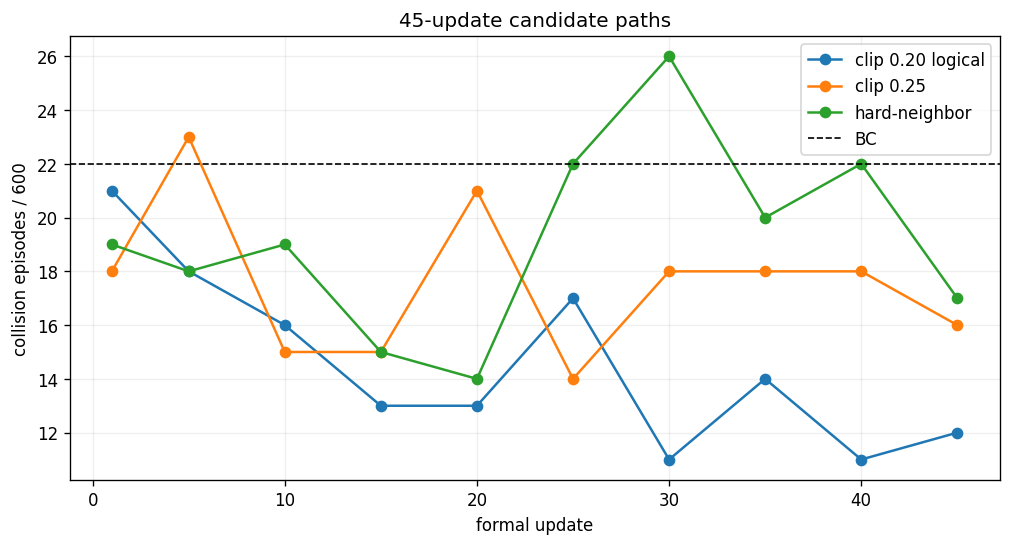

In [5]:
valid = panels[(panels.group != 'BC') & panels.summary_valid].copy()
paths = valid.pivot_table(index=['group','arm','run'], columns='update', values='collision_count', aggfunc='first')
display(paths)

fig, ax = plt.subplots(figsize=(10, 4.8))
for label, frame in [
    ('clip 0.20 logical', logical),
    ('clip 0.25', valid[valid.group.eq('G8')]),
    ('hard-neighbor', valid[valid.group.eq('G9')]),
]:
    frame = frame.sort_values('update')
    ax.plot(frame['update'], frame.collision_count, marker='o', label=label)
ax.axhline(summary['bc_collision_count'], color='black', linestyle='--', linewidth=1, label='BC')
ax.set(xlabel='formal update', ylabel='collision episodes / 600', title='45-update candidate paths')
ax.legend()
ax.grid(alpha=.2)
plt.show()


## Exact episode-paired comparison against BC

In [6]:
display(paired)

transition = (episodes.groupby(['group','run','update','collision_transition'])
              .size().rename('episodes').reset_index())
display(transition.sort_values(['group','run','update','collision_transition']))


,comparison,left_run,left_update,right_run,right_update,left_collisions,right_collisions,shared_collisions,resolved_left_collisions,created_right_collisions,net_collision_change,exact_paired_p_unadjusted
0,BC -> G1 base U20,BC,0,ppo_privilege_gru_0721_base,20,22,14,12,10,2,-8,0.038574
1,BC -> G5 clip0.20 U30,BC,0,ppo_privilege_gru_0722_long_clip020,30,22,11,5,17,6,-11,0.034690
2,BC -> G7 clip0.20 U40,BC,0,ppo_privilege_gru_0722_long45_clip020,40,22,11,7,15,4,-11,0.019211
3,BC -> G7 clip0.20 U45,BC,0,ppo_privilege_gru_0722_long45_clip020,45,22,12,7,15,5,-10,0.041389
4,BC -> G8 clip0.25 U45,BC,0,ppo_privilege_gru_0722_long45_clip025,45,22,16,10,12,6,-6,0.237885
5,BC -> G9 hard U20,BC,0,ppo_privilege_gru_0722_long45_clip020_hard,20,22,14,11,11,3,-8,0.057373
6,BC -> G9 hard U45,BC,0,ppo_privilege_gru_0722_long45_clip020_hard,45,22,17,7,15,10,-5,0.424356
7,G7 vs G9 U30,ppo_privilege_gru_0722_long_clip020,30,ppo_privilege_gru_0722_long45_clip020_hard,30,11,26,6,5,20,15,0.004077
8,G7 vs G9 U45,ppo_privilege_gru_0722_long45_clip020,45,ppo_privilege_gru_0722_long45_clip020_hard,45,12,17,3,9,14,5,0.404873
9,G7 vs G8 U45,ppo_privilege_gru_0722_long45_clip020,45,ppo_privilege_gru_0722_long45_clip025,45,12,16,5,7,11,4,0.480682


,group,run,update,collision_transition,episodes
0,BC,BC,0,both_success,578
1,BC,BC,0,persistent,22
2,G1,ppo_independent_gru_0721_base,1,both_success,574
3,G1,ppo_independent_gru_0721_base,1,created,4
4,G1,ppo_independent_gru_0721_base,1,persistent,15
5,G1,ppo_independent_gru_0721_base,1,resolved,7
6,G1,ppo_independent_gru_0721_base,5,both_success,568
7,G1,ppo_independent_gru_0721_base,5,created,10
8,G1,ppo_independent_gru_0721_base,5,persistent,9
9,G1,ppo_independent_gru_0721_base,5,resolved,13


## Collision commonality

,scenario_id,episode_key,bc_collision,ppo_eval_panel_count,ppo_observed_panel_count,ppo_collision_panel_count,ppo_collision_panel_rate,ppo_final_run_count,ppo_observed_final_run_count,ppo_final_collision_count,ppo_final_collision_rate,ppo_structural_tail_panel_count,ppo_strict_5deg_tail_panel_count
0,evaluation-sp17-ego727-raceline2-v0.5,ol2_e727_o745_s0.5,True,92,92,92,1.000000,16,16,16,1.0000,0,0
1,evaluation-sp35-ego1497-raceline1-v0.5,ol1_e1497_o1512_s0.5,True,92,92,92,1.000000,16,16,16,1.0000,0,0
2,evaluation-sp5-ego213-raceline0-v0.7,ol0_e213_o221_s0.7,True,92,92,79,0.858696,16,16,12,0.7500,79,79
3,evaluation-sp32-ego1368-raceline1-v0.6,ol1_e1368_o1383_s0.6,True,92,92,67,0.728261,16,16,10,0.6250,0,0
4,evaluation-sp15-ego641-raceline2-v0.7,ol2_e641_o661_s0.7,True,92,92,66,0.717391,16,16,8,0.5000,66,56
5,evaluation-sp17-ego727-raceline2-v0.7,ol2_e727_o745_s0.7,True,92,92,59,0.641304,16,16,9,0.5625,18,0
6,evaluation-sp36-ego1539-raceline1-v0.5,ol1_e1539_o1554_s0.5,False,92,92,55,0.597826,16,16,12,0.7500,19,12
7,evaluation-sp35-ego1497-raceline1-v0.6,ol1_e1497_o1512_s0.6,True,92,92,51,0.554348,16,16,7,0.4375,3,0
8,evaluation-sp21-ego898-raceline0-v0.7,ol0_e898_o902_s0.7,True,92,92,49,0.532609,16,16,8,0.5000,40,39
9,evaluation-sp9-ego384-raceline0-v0.7,ol0_e384_o391_s0.7,True,92,92,49,0.532609,16,16,8,0.5000,15,9


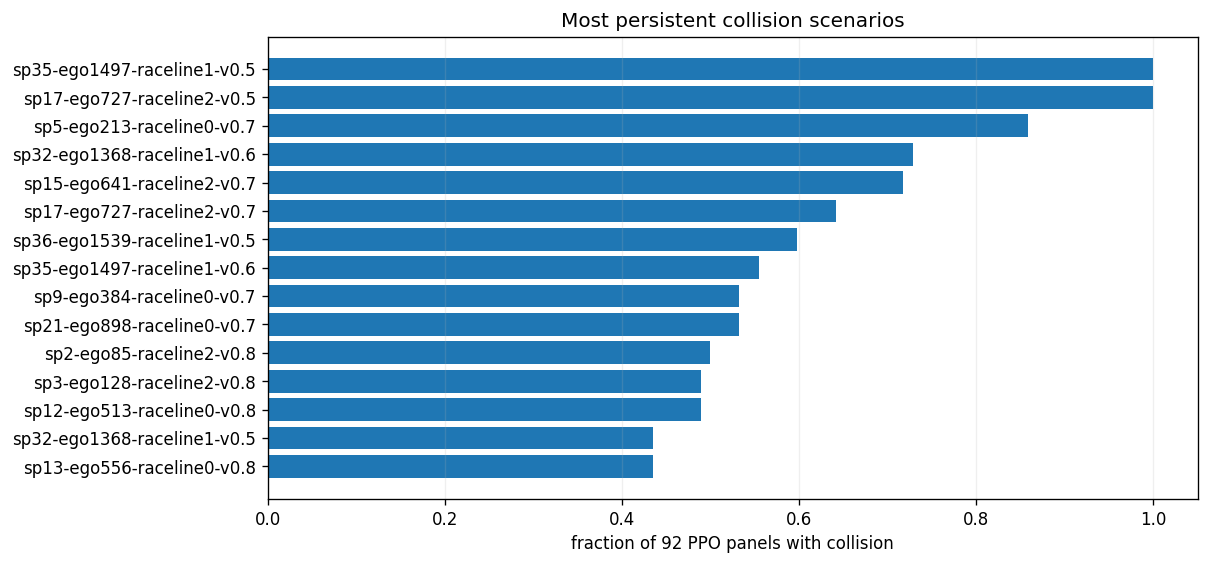

In [7]:
top = frequency.sort_values(['ppo_collision_panel_count','scenario_id'], ascending=[False, True]).head(15)
display(top)

fig, ax = plt.subplots(figsize=(10, 5))
plot = top.sort_values('ppo_collision_panel_rate')
ax.barh(plot.scenario_id.str.replace('evaluation-', '', regex=False), plot.ppo_collision_panel_rate)
ax.set(xlabel='fraction of 92 PPO panels with collision', title='Most persistent collision scenarios')
ax.grid(axis='x', alpha=.2)
plt.show()


两个场景在 92/92 PPO 面板均碰撞：`sp17-ego727-raceline2-v0.5` 与 `sp35-ego1497-raceline1-v0.5`，它们主要是稳定的早期/前向接触，并非甩尾。最持续的甩尾型场景是 `sp5-ego213-raceline0-v0.7`：79/92 面板碰撞，且发生碰撞时 79/79 都满足结构性尾部接触和严格 5° 判据。

## Did PPO solve the inherited post-overtake tail-swing failure?

,checkpoint,collisions,vehicle,wall,structural_tail,strict_tail_3deg,strict_tail_5deg,strict_tail_8deg,BC_strict_resolved,new_strict_vs_BC
0,BC,22,21,1,12,10,8,7,0,0
1,G5 clip.20 U30,11,11,0,5,3,3,2,7,2
2,G7 clip.20 U40,11,11,0,8,5,5,3,7,4
3,G7 clip.20 U45,12,11,1,7,7,6,4,5,3
4,G8 clip.25 U45,16,16,0,8,7,5,3,4,1
5,G9 hard U20,14,14,0,7,6,6,5,4,2
6,G9 hard U45,17,17,0,5,1,1,1,7,0


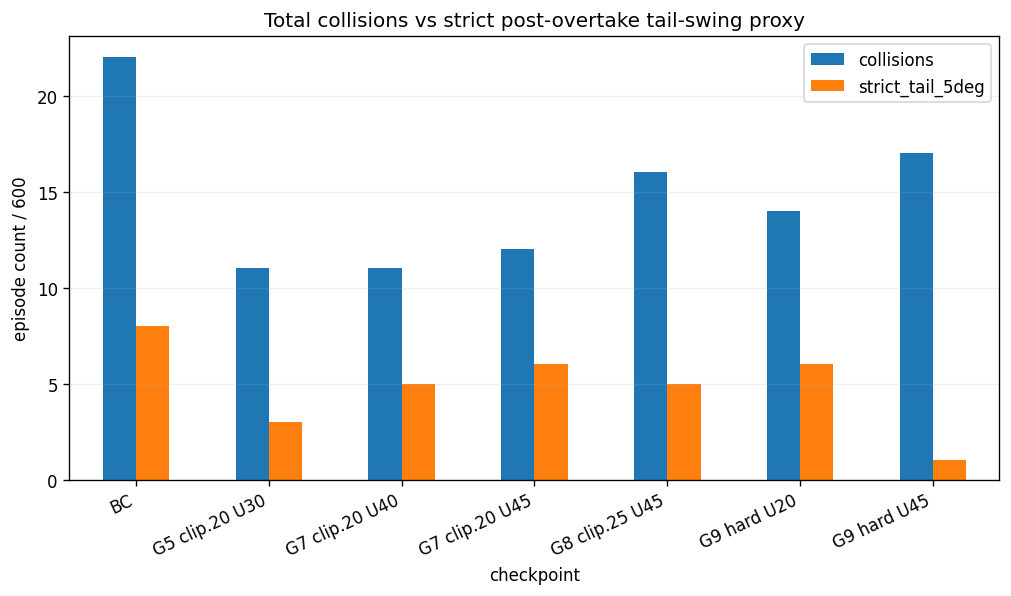

In [8]:
wanted = {
    ('BC', 0): 'BC',
    ('ppo_privilege_gru_0722_long_clip020', 30): 'G5 clip.20 U30',
    ('ppo_privilege_gru_0722_long45_clip020', 40): 'G7 clip.20 U40',
    ('ppo_privilege_gru_0722_long45_clip020', 45): 'G7 clip.20 U45',
    ('ppo_privilege_gru_0722_long45_clip025', 45): 'G8 clip.25 U45',
    ('ppo_privilege_gru_0722_long45_clip020_hard', 20): 'G9 hard U20',
    ('ppo_privilege_gru_0722_long45_clip020_hard', 45): 'G9 hard U45',
}
rows=[]
for (run, update), label in wanted.items():
    row = panels[(panels.run == run) & (panels['update'] == update)].iloc[0]
    rows.append({
        'checkpoint': label,
        'collisions': row.collision_count,
        'vehicle': row.vehicle_collision_count,
        'wall': row.wall_only_collision_count,
        'structural_tail': row.post_overtake_rear_contact_count,
        'strict_tail_3deg': row.high_sideslip_tail_3deg_count,
        'strict_tail_5deg': row.high_sideslip_tail_5deg_count,
        'strict_tail_8deg': row.high_sideslip_tail_8deg_count,
        'BC_strict_resolved': row.bc_strict_5deg_tail_scenarios_resolved,
        'new_strict_vs_BC': row.new_strict_5deg_tail_scenarios_vs_bc,
    })
tail_selected = pd.DataFrame(rows)
display(tail_selected)

ax = tail_selected.set_index('checkpoint')[['collisions','strict_tail_5deg']].plot.bar(figsize=(10,4.8))
ax.set(ylabel='episode count / 600', title='Total collisions vs strict post-overtake tail-swing proxy')
ax.grid(axis='y', alpha=.2)
plt.xticks(rotation=25, ha='right')
plt.show()


In [9]:
bc_strict = pd.read_csv(OUT / 'bc_tail_scenario_outcomes.csv')
selected = bc_strict[bc_strict.run.isin([
    'BC',
    'ppo_privilege_gru_0722_long_clip020',
    'ppo_privilege_gru_0722_long45_clip020',
    'ppo_privilege_gru_0722_long45_clip025',
    'ppo_privilege_gru_0722_long45_clip020_hard',
])]
selected = selected[
    ((selected.run == 'BC') & (selected['update'] == 0)) |
    ((selected.run.str.endswith('long_clip020')) & (selected['update'] == 30)) |
    ((selected.run.str.endswith('long45_clip020')) & selected['update'].isin([40,45])) |
    ((selected.run.str.endswith('long45_clip025')) & (selected['update'] == 45)) |
    ((selected.run.str.endswith('long45_clip020_hard')) & selected['update'].isin([20,45]))
]
display(selected.pivot_table(index='scenario_id', columns=['run','update'], values='high_sideslip_tail_5deg', aggfunc='first'))


run                                        BC  ... ppo_privilege_gru_0722_long_clip020
update                                     0   ...                                  30
scenario_id                                    ...                                    
evaluation-sp1-ego42-raceline2-v0.7      True  ...                               False
evaluation-sp12-ego513-raceline0-v0.8   False  ...                               False
evaluation-sp13-ego556-raceline0-v0.8    True  ...                               False
evaluation-sp15-ego641-raceline2-v0.7    True  ...                               False
evaluation-sp2-ego85-raceline2-v0.8      True  ...                               False
evaluation-sp21-ego898-raceline0-v0.7    True  ...                                True
evaluation-sp30-ego1283-raceline0-v0.7  False  ...                               False
evaluation-sp37-ego1582-raceline2-v0.7   True  ...                               False
evaluation-sp4-ego171-raceline2-v0.8     True  ...                               False
evaluation-sp45-ego1924-raceline0-v0.7  False  ...                               False
evaluation-sp5-ego213-raceline0-v0.7     True  ...                               False
evaluation-sp9-ego384-raceline0-v0.7    False  ...                               False

[12 rows x 7 columns]

## Takeaways

1. **总体安全候选仍是普通 clip 0.20。** G5 U30 与 G7 U40 都是 11/600；G7 U45 为 12/600。45U 没有形成继续单调下降，而是进入 11–14 的波动平台。
2. **clip 0.25 没有继续改善。** U45 为 16/600，整条 45U 路径也没有优于 clip 0.20 的 11。
3. **PPO 对 BC 甩尾是部分修复。** G5 U30 解决 BC 8 个严格甩尾中的 7 个，但又产生 2 个新严格甩尾；G7 U40 同样解决 7 个，却新增 4 个。
4. **hard-neighbor 是机制定向改善，不是总体 winner。** U45 严格甩尾只剩 1 个、没有新增严格甩尾，但总碰撞 17，并新增 10 个 BC 未碰撞场景，说明失败被转移。
5. **不要用单点或训练 metrics 宣称收敛/泛化。** 所有结果来自单 seed 和同一固定面板；Austin600 还含 8 组重复物理初态。应先修正面板生成，再做预注册 checkpoint 的 holdout 复评。
